In [1]:
import os
import sys

sys.path.append(os.path.abspath("../src"))

from utils import load_dataset, dataset_info
from eda import perform_eda
from preprocessing import preprocess_data
from feature_selection import select_features
from classification import train_classification
from metrics import classification_metrics

from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.neighbors import KNeighborsClassifier

import pandas as pd
import numpy as np
import time

In [2]:
df = load_dataset("spambase.csv")

In [3]:
dataset_info(df)

DATASET INFORMATION

Shape : (4601, 58)

Columns
['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B

In [4]:
print(df.columns.tolist())

['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct', 'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_%3B', 'char_freq_%28', 'char_freq_%5B', 'char_freq_%21', 'char_freq_%24', 'char_freq_%

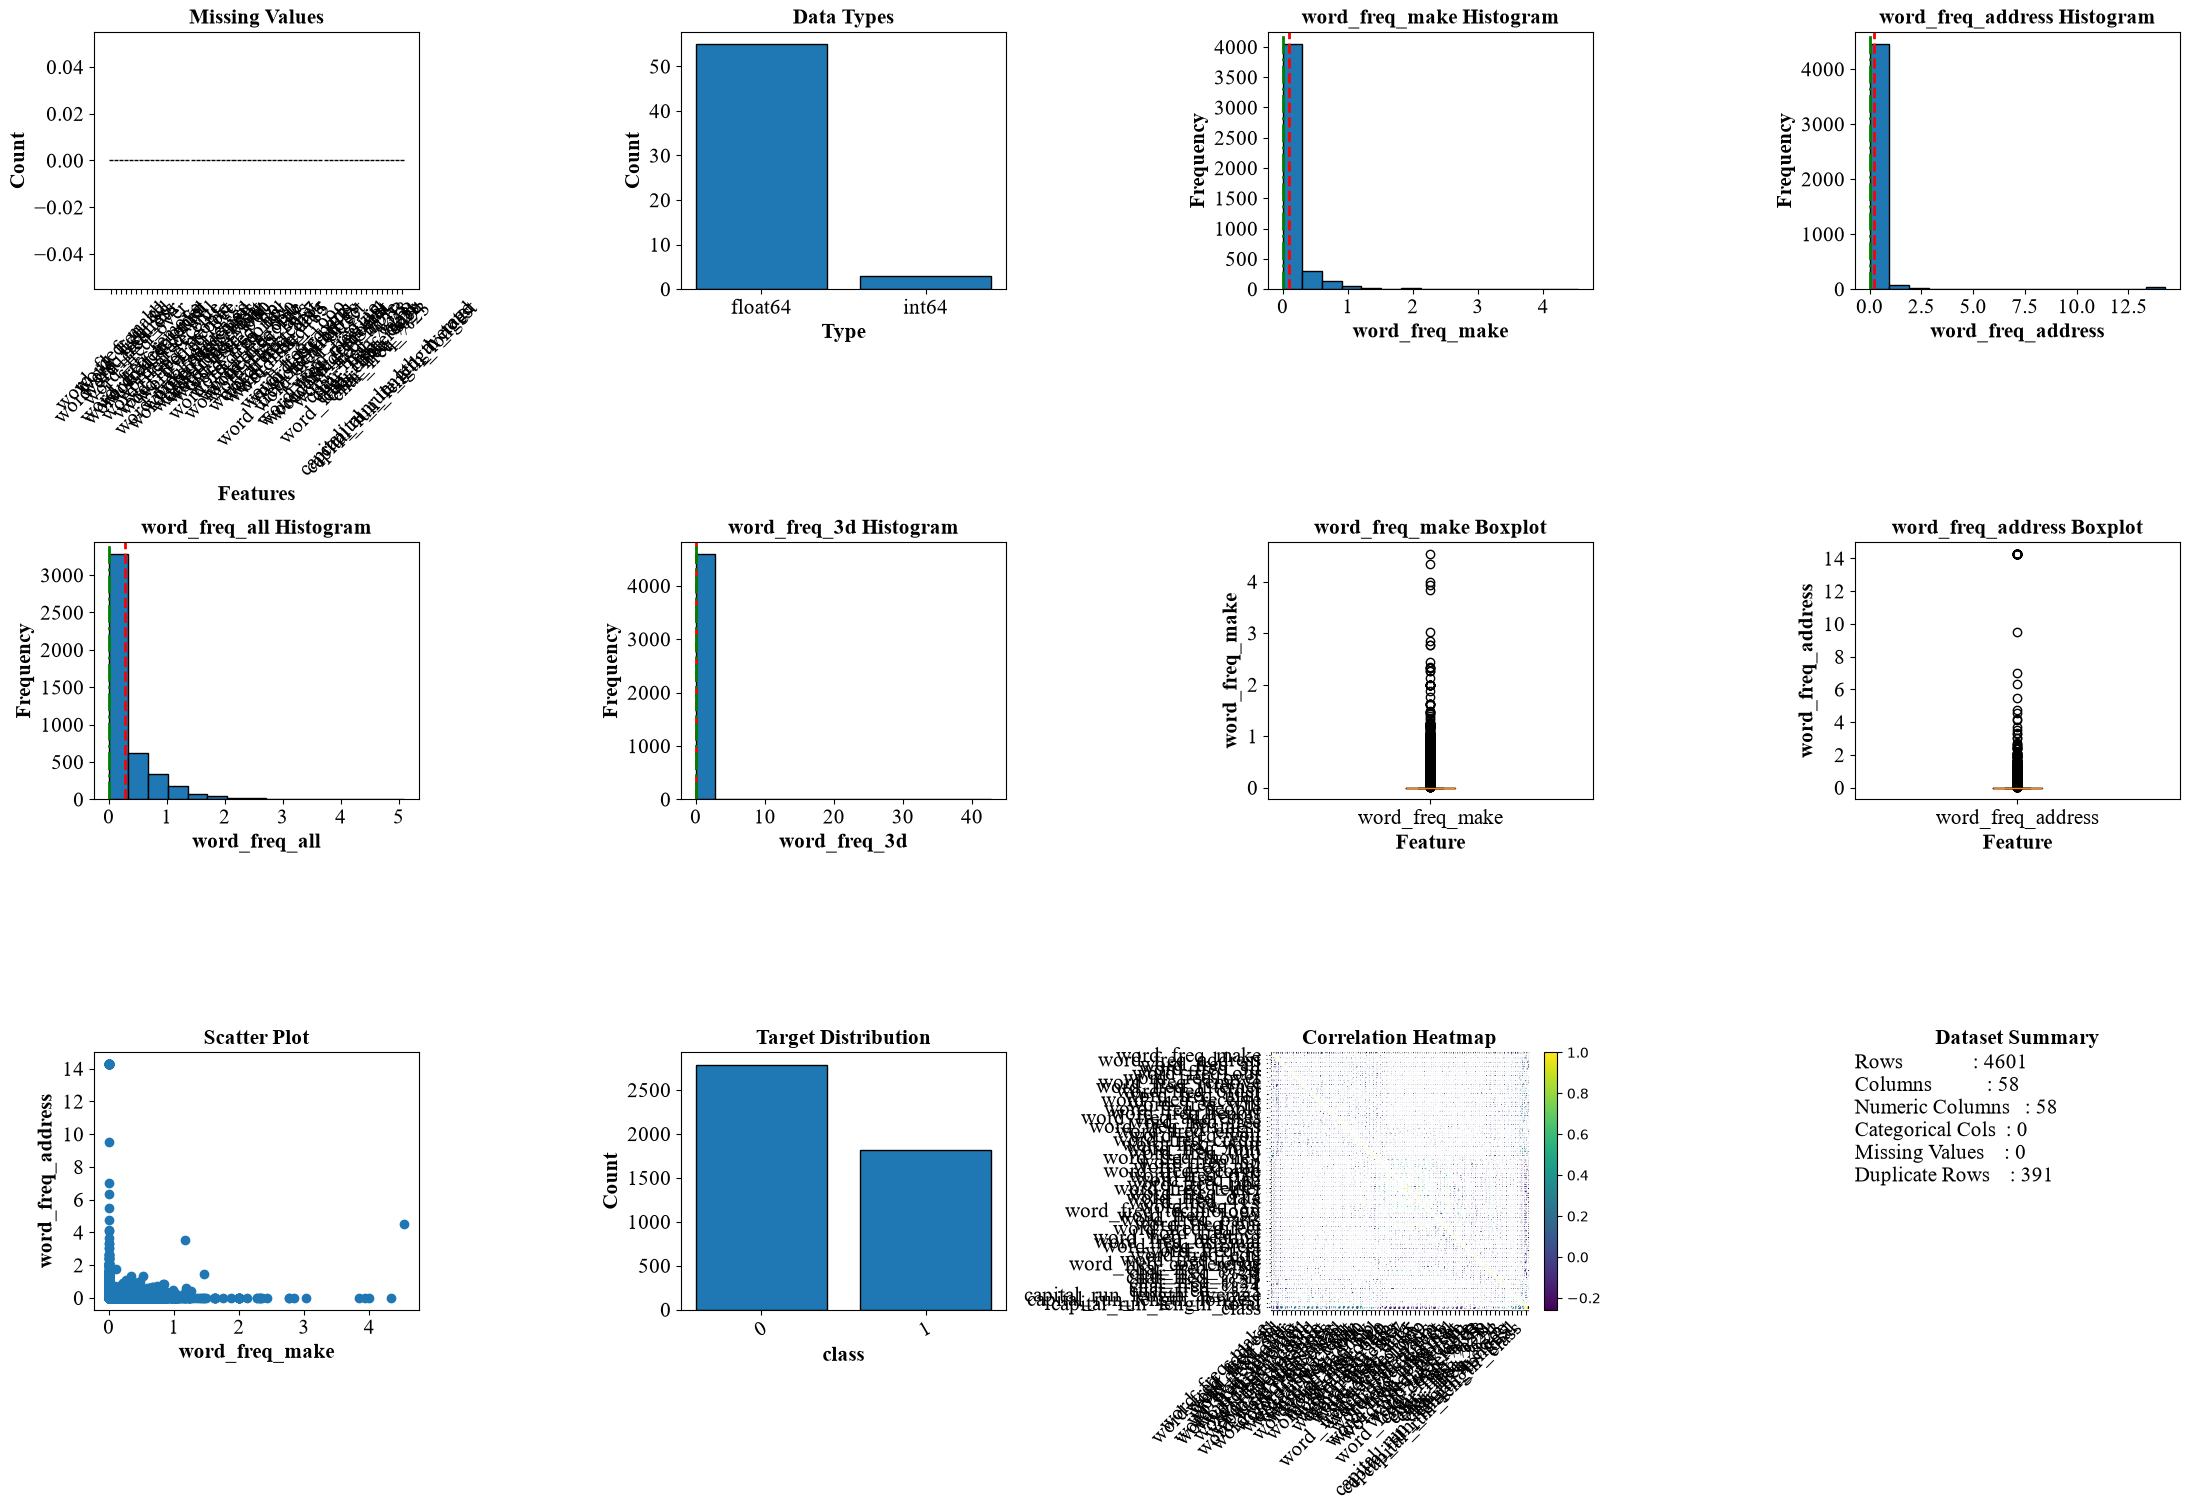

In [5]:
summary = perform_eda(
    df=df,
    target_column="class",
    save=True,
    filename="spambase_eda"
)

In [6]:
'''Preprocessing (Scaled)

Used for

GaussianNB
KNN'''
X_train, X_test, y_train, y_test, scaler, encoders = preprocess_data(
    df=df,
    target_column="class",
    drop_cols=None,
    encode=True,
    scale=True,
    stratify=True,
    test_size=0.2,
    random_state=42
)

In [7]:
'''Preprocessing (Without Scaling)

Used for

MultinomialNB
BernoulliNB'''

X_train_nb, X_test_nb, y_train_nb, y_test_nb, _, _ = preprocess_data(
    df=df,
    target_column="class",
    drop_cols=None,
    encode=True,
    scale=False,
    stratify=True,
    test_size=0.2,
    random_state=42
)

In [8]:
X_train, X_test, selector = select_features(
    X_train,
    X_test,
    y_train,
    method="anova",
    k="all"
)

X_train_nb, X_test_nb, selector = select_features(
    X_train_nb,
    X_test_nb,
    y_train_nb,
    method="anova",
    k="all"
)


========== Classification Metrics ==========

Accuracy : 0.8290
Precision: 0.8616
Recall   : 0.8290
F1 Score : 0.8306

Confusion Matrix

[[378 128]
 [ 16 320]]

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       506
           1       0.71      0.95      0.82       336

    accuracy                           0.83       842
   macro avg       0.84      0.85      0.83       842
weighted avg       0.86      0.83      0.83       842

ROC AUC  : 0.9471


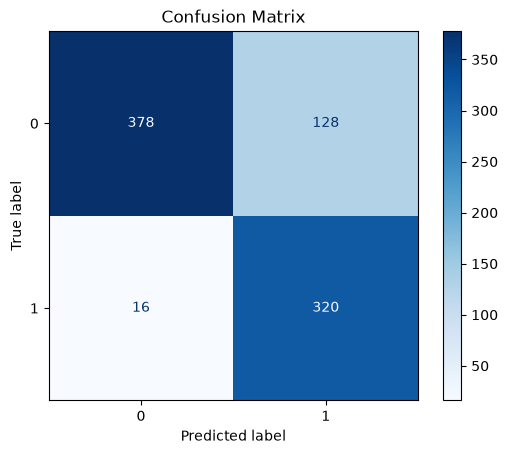

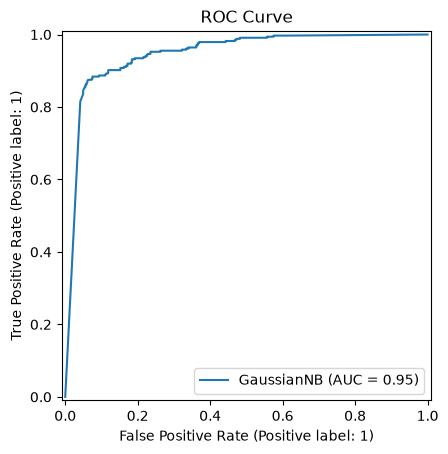

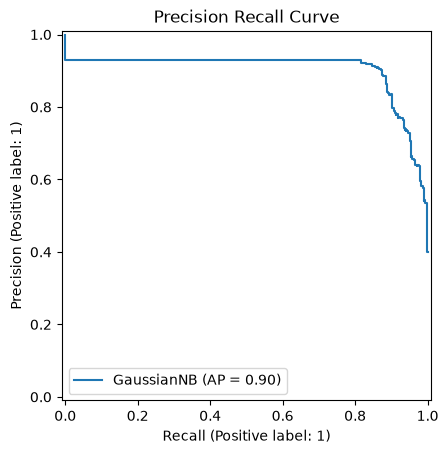

In [9]:
gaussian_nb = train_classification(
    X_train,
    y_train,
    algorithm="gaussian_nb"
)

gaussian_predictions = classification_metrics(
    gaussian_nb,
    X_test,
    y_test
)


========== Classification Metrics ==========

Accuracy : 0.7886
Precision: 0.7869
Recall   : 0.7886
F1 Score : 0.7864

Confusion Matrix

[[434  72]
 [106 230]]

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.86      0.83       506
           1       0.76      0.68      0.72       336

    accuracy                           0.79       842
   macro avg       0.78      0.77      0.78       842
weighted avg       0.79      0.79      0.79       842

ROC AUC  : 0.8342


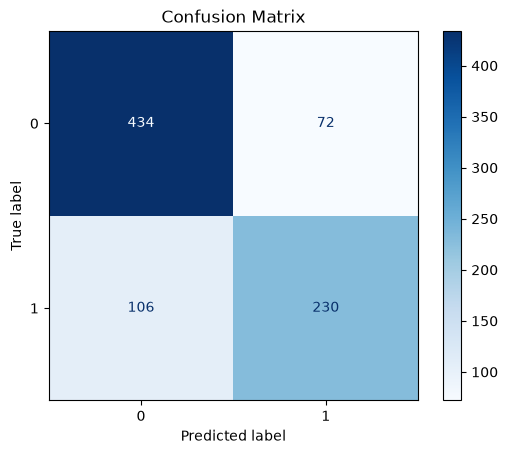

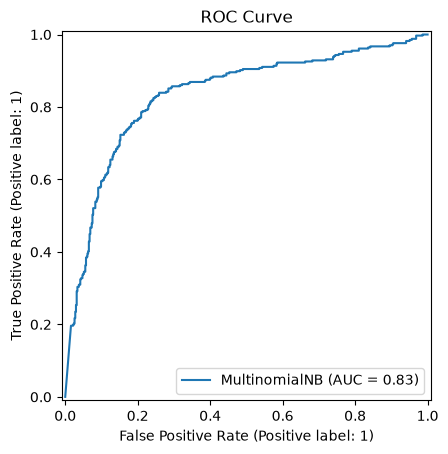

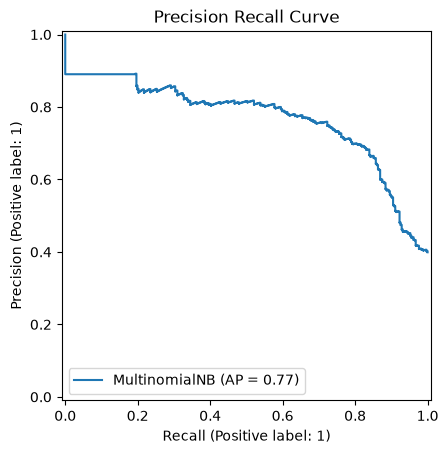

In [10]:
multinomial_nb = train_classification(
    X_train_nb,
    y_train_nb,
    algorithm="multinomial_nb"
)

multinomial_predictions = classification_metrics(
    multinomial_nb,
    X_test_nb,
    y_test_nb
)


========== Classification Metrics ==========

Accuracy : 0.8943
Precision: 0.8940
Recall   : 0.8943
F1 Score : 0.8940

Confusion Matrix

[[466  40]
 [ 49 287]]

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       506
           1       0.88      0.85      0.87       336

    accuracy                           0.89       842
   macro avg       0.89      0.89      0.89       842
weighted avg       0.89      0.89      0.89       842

ROC AUC  : 0.9609


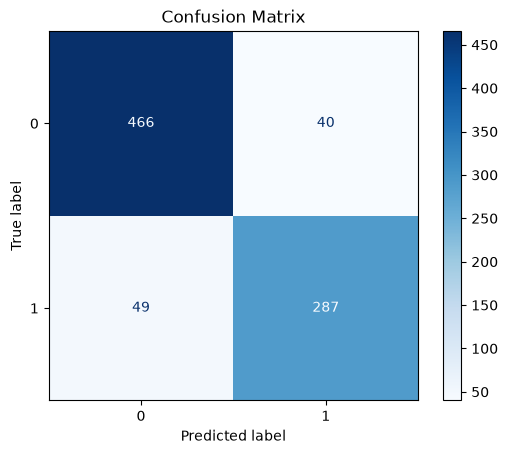

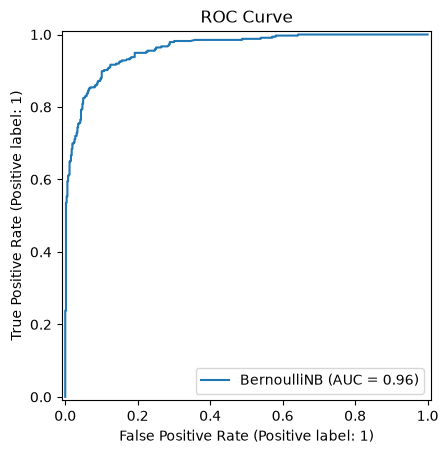

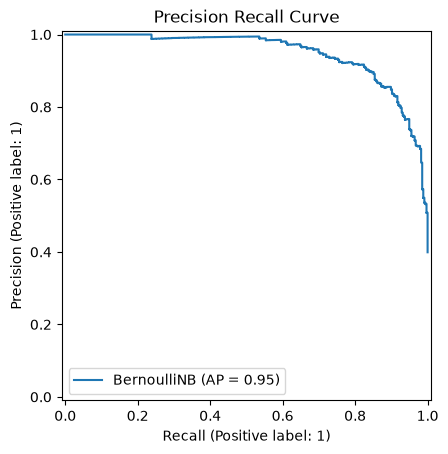

In [11]:
bernoulli_nb = train_classification(
    X_train_nb,
    y_train_nb,
    algorithm="bernoulli_nb"
)

bernoulli_predictions = classification_metrics(
    bernoulli_nb,
    X_test_nb,
    y_test_nb
)


========== Classification Metrics ==========

Accuracy : 0.9109
Precision: 0.9111
Recall   : 0.9109
F1 Score : 0.9104

Confusion Matrix

[[479  27]
 [ 48 288]]

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       506
           1       0.91      0.86      0.88       336

    accuracy                           0.91       842
   macro avg       0.91      0.90      0.91       842
weighted avg       0.91      0.91      0.91       842

ROC AUC  : 0.9548


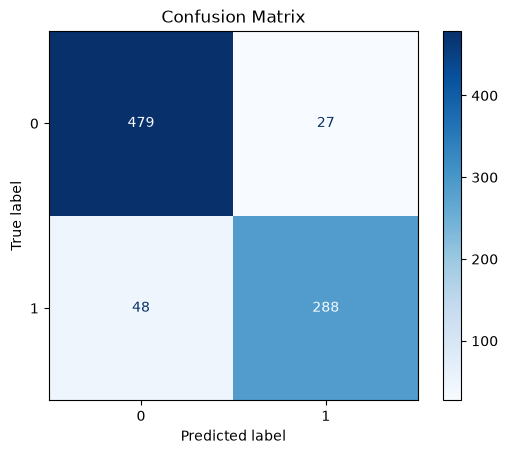

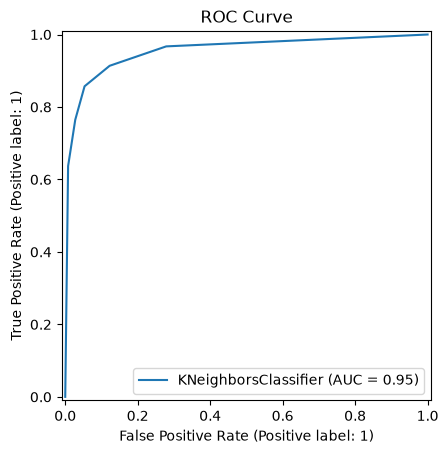

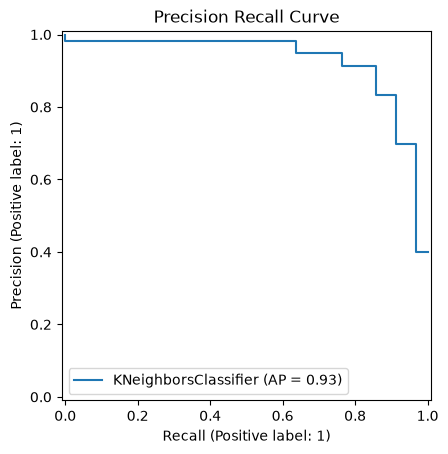

In [12]:
knn = train_classification(
    X_train,
    y_train,
    algorithm="knn",
    k=5
)

knn_predictions = classification_metrics(
    knn,
    X_test,
    y_test
)

In [13]:
k_values = [1,3,5,7,9,11]

accuracies = []

for k in k_values:

    model = train_classification(
        X_train,
        y_train,
        algorithm="knn",
        k=k
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    accuracies.append(accuracy)

print(pd.DataFrame({
    "k":k_values,
    "Accuracy":accuracies
}))

    k  Accuracy
0   1  0.904988
1   3  0.902613
2   5  0.910926
3   7  0.908551
4   9  0.902613
5  11  0.901425


In [14]:
parameters = {

    "n_neighbors":[1,3,5,7,9,11],

    "weights":["uniform","distance"],

    "metric":["euclidean","manhattan"],

    "algorithm":["auto","kd_tree","ball_tree"]

}

grid = GridSearchCV(

    KNeighborsClassifier(),

    parameters,

    cv=5,

    scoring="accuracy"

)

grid.fit(

    X_train,

    y_train

)

print("Best Parameters")

print(grid.best_params_)

print()

print("Best Accuracy")

print(grid.best_score_)

Best Parameters
{'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}

Best Accuracy
0.9112239364023969


In [15]:
random = RandomizedSearchCV(

    KNeighborsClassifier(),

    parameters,

    cv=5,

    n_iter=10,

    random_state=42

)

random.fit(

    X_train,

    y_train

)

print("Best Parameters")

print(random.best_params_)

print()

print("Best Accuracy")

print(random.best_score_)

Best Parameters
{'weights': 'uniform', 'n_neighbors': 3, 'metric': 'manhattan', 'algorithm': 'ball_tree'}

Best Accuracy
0.9014219514023306


In [16]:
for algo in ["kd_tree","ball_tree"]:

    start = time.time()

    model = train_classification(

        X_train,

        y_train,

        algorithm="knn",

        algorithm_type=algo

    )

    train_time = time.time()-start

    start = time.time()

    predictions = model.predict(X_test)

    predict_time = time.time()-start

    accuracy = model.score(

        X_test,

        y_test

    )

    print()

    print(algo)

    print("Accuracy :",accuracy)

    print("Training :",train_time)

    print("Prediction :",predict_time)


kd_tree
Accuracy : 0.9109263657957245
Training : 0.0318608283996582
Prediction : 0.20894980430603027

ball_tree
Accuracy : 0.9109263657957245
Training : 0.01859736442565918
Prediction : 0.1791238784790039


In [17]:
scores = cross_val_score(

    knn,

    X_train,

    y_train,

    cv=5

)

print("Fold Scores")

print(scores)

print()

print("Average")

print(scores.mean())

Fold Scores
[0.89169139 0.89020772 0.90059347 0.89301634 0.90193165]

Average
0.8954881151317675


In [18]:
models = {

    "GaussianNB": gaussian_nb,

    "MultinomialNB": multinomial_nb,

    "BernoulliNB": bernoulli_nb,

    "KNN": knn

}

for name in models:

    print(name)

GaussianNB
MultinomialNB
BernoulliNB
KNN
